# IrriGator — Full End-to-End Pipeline

Central notebook covering **every block** from raw data to irrigation recommendation.

| Block | What | Data source | Run frequency |
|-------|------|-------------|---------------|
| 0 | Data ingestion | ERA5-Land (France-wide), COMEPHORE, Sentinel-2, soil, DEM | Once (historical archive) |
| 1 | Static layers | EU-SoilHydroGrids, IGN DEM | Once per parcel |
| 2 | Atmospheric forcing | ERA5-Land daily → parcel extraction | Once (cache), then per parcel |
| 3+4 | Simulation | Water balance + crop growth ACQUACROP | Daily |
| 5a | Short-term forecast | AROME (0-48h) + IFS ENS (0-15d) → ensemble | Daily |
| 5b | Seasonal outlook | SEAS5 → PCA analog → ensemble water balance | Monthly |
| 6 | Decision | Ensemble stress → irrigation recommendation | Daily |

**Architecture change:** ERA5-Land is now downloaded once for all of metropolitan
France (41°N–51.5°N, 6°W–10°E). Any new parcel is served from this cache
without additional API calls. AROME and IFS ENS already work the same way.

---
## Configuration — set your "today" and paths here

In [1]:
import logging
import os
from datetime import date
from pathlib import Path
from datetime import timedelta

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

TODAY = date(2023, 12, 31)          # the date we treat as "today"
#TODAY = date.today()
SIMULATION_START = date(2023, 1, 1) # start of the growing season simulation
LAST_IRRIGATION = None              # date of last irrigation, or None for rainfed
RUN_SEAS5 = False                   # set True to include seasonal outlook (slow)
SHIFT = 0                           # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")                # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")     # daily aggregates, cached results

# Parcel and region configs (region still needed for static layers)
REGION_CONFIG = "configs/ain.yaml"
PARCEL_CONFIG = "configs/parcels/kopri.yaml"
PARCEL_CONFIG2 = "configs/parcels/example.yaml"
CROP_PARAMS_PATH = "configs/crop_parameters.yaml"
MODEL_PARAMS_PATH = "configs/model_parameters.yaml"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Repo root: {REPO_ROOT}")
print(f"Today:     {TODAY}")
print(f"Raw dir:   {RAW_DIR}")
print(f"Processed: {PROCESSED_DIR}")

Repo root: /home/mbaldacchino/code/IrriGator
Today:     2023-12-31
Raw dir:   data/raw
Processed: data/processed


---
## Block 0 — Data Ingestion

Run these cells **once** to download and cache the historical archive.
Skip if data is already on disk.

ERA5-Land is downloaded for all of France — not per region. One download
covers any parcel in metropolitan France.

In [2]:
from irrigator.config import load_region_config, load_parcel_config

cfg = load_region_config(REGION_CONFIG)
parcel = load_parcel_config(PARCEL_CONFIG)
parcel2 = load_parcel_config(PARCEL_CONFIG2)

print(f"Region: {cfg.name} (dept {cfg.code_departement})")
print(f"Parcel: {parcel.name} ({parcel.id})")
print(f"Crop:   {parcel.crop.get('type')} — planting {parcel.crop.get('planting_date')}")

Region: Ain (dept 01)
Parcel: Parcelle Principale - Kopri (kopri_001)
Crop:   grain_maize — planting 2026-01-01


In [5]:
# --- ERA5-Land download (skip if already done) ---
# France-wide, no per-region dependency
from irrigator.ingestion.cds_client import fetch_era5_land_range
fetch_era5_land_range(date(2020, 1, 1), date.today(), raw_dir=RAW_DIR, overwrite=False, force_cds_refresh=False)

08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-01 already exists: data/raw/era5_land/era5land_2020_01.nc


08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-02 already exists: data/raw/era5_land/era5land_2020_02.nc
08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-03 already exists: data/raw/era5_land/era5land_2020_03.nc
08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-04 already exists: data/raw/era5_land/era5land_2020_04.nc
08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-05 already exists: data/raw/era5_land/era5land_2020_05.nc
08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-06 already exists: data/raw/era5_land/era5land_2020_06.nc
08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-07 already exists: data/raw/era5_land/era5land_2020_07.nc
08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-08 already exists: data/raw/era5_land/era5land_2020_08.nc
08:05:50 [irrigator.ingestion.cds_client] INFO: ERA5-Land 2020-09 already exists: data/raw/era5_land/era5land_2020_09.nc
08:05:50 [irrigator.ingestion.cd

KeyboardInterrupt: 

In [3]:
# --- Build static layers (skip if already done) ---
# These still use RegionConfig because they depend on the regional DEM/soil grids
from irrigator.ingestion.esdac_loader import load_soil_hydro, save_soil_hydro
from irrigator.ingestion.ign_loader import load_terrain, save_terrain
from irrigator.ingestion.grid import build_grid

grid = build_grid(cfg)
soil_grid = load_soil_hydro(cfg, grid)
save_soil_hydro(soil_grid, cfg.processed_dir / "static")
terrain_grid = load_terrain(cfg, grid)
save_terrain(terrain_grid, cfg.processed_dir / "static")

08:42:56 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
08:42:56 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.
08:42:56 [irrigator.ingestion.grid] INFO: Grid built: 440 x 400 (176000 cells) at 250 m in EPSG:2154
08:42:56 [irrigator.ingestion.esdac_loader] INFO: Using tile index: /home/mbaldacchino/code/IrriGator/data/static/eu_soilhydrogrids/grid_cells_250m_wgs84.gpkg
08:42:56 [irrigator.ingestion.esdac_loader] INFO: Tile index: 4 tiles intersect region, 4 exist on disk
08:42:56 [irrigator.ingestion.esdac_loader] INFO: Loading EU-SoilHydroGrids: 4 variables × 6 layers from 4 tiles
08:42:56 [irrigator.ingestion.esdac_loader] INFO: Loaded FC: 6 layers
08:42:57 [irrigator.ingestion.esdac_loader] INFO: Loaded WP: 6 layers
08:42:57 [irrigator.ingestion.esdac_loader] INFO: Loaded KS: 6 layers
08:42:57 [irrigator.ingestion.esdac_loader] INFO: Loaded THS: 6 layers


KeyboardInterrupt: 

---
## Block 1 — Static Layers (parcel-level)

Extract soil and terrain at the parcel location. Run once per parcel, cache.

In [3]:
from irrigator.static_layers.soil import get_soil_profile
from irrigator.static_layers.terrain import get_terrain_params, get_era5_elevation

soil = get_soil_profile(cfg, parcel)
terrain = get_terrain_params(cfg, parcel)
terrain.era5_elevation_m = get_era5_elevation(cfg, parcel)
terrain.era5_elevation_m = terrain.elevation_m # fix for kopri

print(f"Soil AWC:  {soil.total_awc_mm:.0f} mm (source: {soil.source})")
print(f"Elevation: {terrain.elevation_m:.0f} m (ERA5 cell: {terrain.era5_elevation_m:.0f} m)")
print(f"Slope:     {terrain.slope_deg:.1f}°")

10:03:26 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
10:03:26 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.
10:03:28 [irrigator.static_layers.soil] INFO: Parcel kopri_001: using EU-SoilHydroGrids — AWC=269 mm, FC=[0.351, 0.337, 0.328, 0.325, 0.315, 0.306]
10:03:28 [irrigator.static_layers.terrain] INFO: Parcel kopri_001 terrain: elev=171 m, slope=1.5°, aspect=173°
10:03:28 [irrigator.ingestion.cds_client] INFO: Opening 120 ERA5-Land files with dask


Soil AWC:  269 mm (source: eu_soilhydrogrids)
Elevation: 171 m (ERA5 cell: 171 m)
Slope:     1.5°


---
## Block 2 — Atmospheric Forcing

Process ERA5-Land hourly → daily (once for all of France), then extract at parcel.

The daily cache is grid-agnostic: any parcel in France can extract its
forcing from the same file via `extract_parcel_forcing()`.

In [4]:
from irrigator.atmospheric.era5_processor import load_daily, process_era5_to_daily, save_daily
from irrigator.atmospheric.forcing import extract_parcel_forcing

# First time: process hourly → daily (slow, do once)
from irrigator.ingestion.cds_client import open_era5_land
era5_hourly = open_era5_land(raw_dir=RAW_DIR, start=SIMULATION_START, end=TODAY)
era5_daily = process_era5_to_daily(era5_hourly, shift_utc=SHIFT)
save_daily(era5_daily, processed_dir=PROCESSED_DIR)

# # After that: just load cached
era5_daily = load_daily(processed_dir=PROCESSED_DIR)
forcing = extract_parcel_forcing(era5_daily, parcel, terrain)

print(f"ERA5 grid: {dict(era5_daily.sizes)}")
print(f"Forcing: {forcing.n_days} days")
print(f"T range: [{forcing.t_min.min():.1f}, {forcing.t_max.max():.1f}] °C")
print(f"Total precip: {forcing.precip_mm.sum():.0f} mm")

10:03:30 [irrigator.ingestion.cds_client] INFO: Opening 12 ERA5-Land files with dask


/home/mbaldacchino/miniconda/envs/cat/lib/python3.13/site-packages/dask/array/reductions.py:291: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(x_chunk, axis=axis, keepdims=keepdims)
10:03:39 [irrigator.atmospheric.era5_processor] INFO: Daily aggregation: 364 days, T range [-31.5, 43.5] °C
10:04:17 [irrigator.atmospheric.era5_processor] INFO: Saved daily ERA5-Land: data/processed/atmospheric/era5_daily.nc (91.8 MB)
10:04:17 [irrigator.atmospheric.forcing] INFO: Parcel kopri_001: extracted 364 days from ERA5-Land at grid cell (5, 46)
10:04:17 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=0 m, ΔT=-0.00°C
10:04:17 [irrigator.atmospheric.forcing] INFO: Parcel kopri_001 forcing: 364 days, T=[-4.4, 39.2]°C, total precip=1132 mm, mean Rs=13.8 MJ/m²/day


ERA5 grid: {'valid_time': 364, 'latitude': 106, 'longitude': 161}
Forcing: 364 days
T range: [-4.4, 39.2] °C
Total precip: 1132 mm


In [5]:
forcing_export = forcing.to_dataframe().round(1)
forcing_export.loc["wind_speed_2m"] = forcing_export["wind_speed_2m"] * 3.6

forcing_export.to_csv("/home/mbaldacchino/data/kopri_parcelle1_2023.csv")

---
## Blocks 3+4 — Historical Simulation up to TODAY

Coupled crop growth + water balance from `SIMULATION_START` to `TODAY`.
The final state is the starting point for the forecast.

In [13]:
from irrigator.water_balance.aquacrop_adapter import run_aquacrop
import pandas as pd

historical_forcing = forcing.slice(SIMULATION_START, TODAY)
LAST_ERA5_DAY = pd.to_datetime(historical_forcing.dates[-1]).date()

hist_run = run_aquacrop(
    forcing=historical_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=LAST_ERA5_DAY,
)

# Daily stress metrics (Ks equivalent, canopy cover, biomass, etc.)
stress = hist_run.daily_stress
# Drop rows past your actual data
valid = stress[stress["dap"] > 0].iloc[:-1]  # drop AquaCrop's terminal zero-row
last = valid.iloc[-1]

print(f"GDD: {last.gdd_cum:.0f}")
print(f"Canopy: {last.canopy_cover:.2f}")
print(f"Ks: {last.ks:.3f}")


IndexError: index -1 is out of bounds for axis 0 with size 0

In [14]:
historical_forcing


DailyForcing(dates=array([], dtype='datetime64[ns]'), t_min=array([], dtype=float64), t_max=array([], dtype=float64), t_mean=array([], dtype=float64), dewpoint=array([], dtype=float64), wind_speed_2m=array([], dtype=float64), pressure_kpa=array([], dtype=float64), rs_mj=array([], dtype=float64), precip_mm=array([], dtype=float64))

<Axes: >

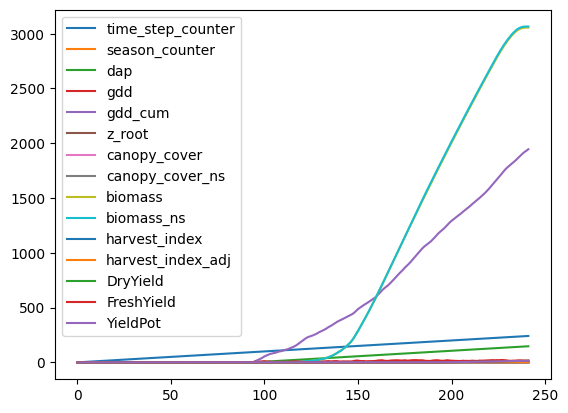

In [19]:
hist_run.crop_growth.plot()

In [27]:
a = hist_run.water_flux
b = hist_run.crop_growth
c = hist_run.daily_stress

In [28]:
a.to_csv("/home/mbaldacchino/data/water_flux.csv")
b.to_csv("/home/mbaldacchino/data/crop_growth.csv")
c.to_csv("/home/mbaldacchino/data/daily_stress.csv")


<Axes: >

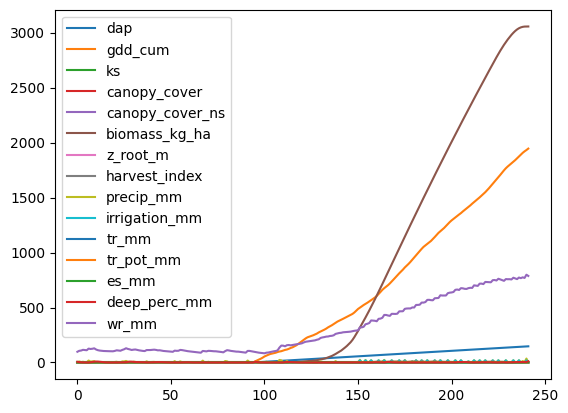

In [23]:
hist_run.daily_stress.plot()

In [9]:
hist_run.final_results

,Season,crop Type,Harvest Date (YYYY/MM/DD),Harvest Date (Step),Dry yield (tonne/ha),Fresh yield (tonne/ha),Yield potential (tonne/ha),Seasonal irrigation (mm)
0,0,MaizeGDD,2025-08-31,241,14.386641,15.985157,14.433645,520.0


In [24]:
hist_run.final_results


,Season,crop Type,Harvest Date (YYYY/MM/DD),Harvest Date (Step),Dry yield (tonne/ha),Fresh yield (tonne/ha),Yield potential (tonne/ha),Seasonal irrigation (mm)
0,0,MaizeGDD,2025-08-31,241,14.386641,15.985157,14.433645,520.0


---
## Block 5a — Operational forecast with AquaCrop

With AquaCrop, forecasting means rerunning the full simulation from Jan 1
with different future forcings appended. This preserves the stress-growth
coupling — a crop that was stressed in June will have smaller canopy in
July, which reduces water demand.

- **AROME** (0-48h): one AquaCrop run with deterministic forecast appended
- **IFS ENS** (0-15d): 50 AquaCrop runs, one per ensemble member
- **Blended report**: AROME days 0-2 (high resolution), IFS ENS days 3+ (ensemble spread)

In [6]:
# --- Cell: Extract current state from historical AquaCrop run ---
# (put this right after Block 3-4)

from irrigator.water_balance.aquacrop_adapter import (
    aquacrop_to_current_state,
    build_blended_stress_report,
    run_ensemble_aquacrop,
)

current_state = aquacrop_to_current_state(hist_run, soil, LAST_ERA5_DAY)

print(f"Current state at {LAST_ERA5_DAY}:")
print(f"  Depletion:  {current_state.depletion:.0f} mm")
print(f"  TAW:        {current_state.taw:.0f} mm")
print(f"  RAW:        {current_state.raw:.0f} mm")
print(f"  Ks:         {current_state.stress_coeff:.3f}")
print(f"  Root depth: {current_state.z_root:.2f} m")
print(f"  GDD:        {current_state.gdd:.0f}")
print(f"  Stage:      {current_state.crop_stage}")


Current state at 2026-06-30:
  Depletion:  149 mm
  TAW:        192 mm
  RAW:        117 mm
  Ks:         0.794
  Root depth: 1.63 m
  GDD:        992
  Stage:      midseason


In [7]:
# --- Cell: Build historical forcing for forecast branching ---

from irrigator.atmospheric.forcing import extract_parcel_forcing
from irrigator.forecasts.arome_processing import load_arome_daily_cache
from datetime import timedelta
import numpy as np

# ERA5-Land historical
era5_last = pd.Timestamp(era5_daily.valid_time.values[-1]).date()
era5_forcing = forcing.slice(SIMULATION_START, era5_last)

# AROME gap fill (era5_last → yesterday)
gap_start = era5_last + timedelta(days=1)
gap_end = TODAY - timedelta(days=1)

if gap_start <= gap_end:
    arome_gap = load_arome_daily_cache(gap_start, gap_end, mode="static")
    gap_forcing = extract_parcel_forcing(arome_gap, parcel, terrain)
    historical_forcing = era5_forcing.concat(gap_forcing)
    print(f"Gap filled: {gap_forcing.n_days} days ({gap_start} → {gap_end})")
else:
    historical_forcing = era5_forcing
    print("No gap to fill")

print(f"Historical forcing: {historical_forcing.n_days} days")

# fake_date = [
#     np.datetime64(date(2026, 6, 24), "ns"),
#     np.datetime64(date(2026, 6, 25), "ns"),
#     np.datetime64(date(2026, 6, 26), "ns"),
# ]
# fake_t_min = [20, 20, 20]
# fake_t_max = [30, 30, 30]
# fake_t_mean = [25, 25, 25]
# fake_dewpoint = [14, 14, 14]
# fake_windspeed = [3, 3, 3]
# fake_press = [101, 101, 101]
# fake_rs = [10, 10, 10]
# fake_precip = [0, 0, 0]
# historical_forcing.dates = np.insert(historical_forcing.dates, 174, fake_date)
# historical_forcing.dewpoint = np.insert(historical_forcing.dewpoint, 174, fake_dewpoint)
# historical_forcing.t_max = np.insert(historical_forcing.t_max, 174, fake_t_max)
# historical_forcing.t_mean = np.insert(historical_forcing.t_mean, 174, fake_t_mean)
# historical_forcing.t_min = np.insert(historical_forcing.t_min, 174, fake_t_min)
# historical_forcing.precip_mm = np.insert(historical_forcing.precip_mm, 174, fake_precip)
# historical_forcing.pressure_kpa = np.insert(historical_forcing.pressure_kpa, 174, fake_press)
# historical_forcing.wind_speed_2m = np.insert(historical_forcing.wind_speed_2m, 174, fake_windspeed)
# historical_forcing.rs_mj = np.insert(historical_forcing.rs_mj, 174, fake_rs)


16:41:59 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 7 days from ERA5-Land at grid cell (0, 45)
16:41:59 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
16:41:59 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 7 days, T=[13.8, 38.4]°C, total precip=0 mm, mean Rs=29.0 MJ/m²/day


Gap filled: 7 days (2026-07-01 → 2026-07-07)
Historical forcing: 188 days


In [8]:
# --- Cell: AROME 48h deterministic forecast ---

arome_today = load_arome_daily_cache(TODAY , TODAY + timedelta(days=1), mode="forecast")
arome_forcing_48h = extract_parcel_forcing(arome_today, parcel, terrain)
# Fix date alignment if needed
arome_forcing_48h.dates = arome_forcing_48h.dates #- np.timedelta64(1, "D")

print(f"AROME forecast: {arome_forcing_48h.n_days} days")
print(f"  T range: [{arome_forcing_48h.t_min.min():.1f}, {arome_forcing_48h.t_max.max():.1f}] °C")

# Run full AquaCrop: historical + AROME 48h
arome_full_forcing = historical_forcing.concat(arome_forcing_48h)


arome_run = run_aquacrop(
    forcing=arome_full_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=pd.Timestamp(arome_full_forcing.dates[-1]).date(),
)

# Quick check: AROME Ks for the forecast days
arome_stress = arome_run.daily_stress
print(f"AROME last 3 days Ks: {arome_stress.ks.iloc[-4:-1].values}")


16:41:59 [arome] WARNING: 1 missing days: [datetime.date(2026, 7, 9)]
16:41:59 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 2 days from ERA5-Land at grid cell (0, 45)
16:41:59 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
16:41:59 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 2 days, T=[19.1, 39.0]°C, total precip=0 mm, mean Rs=29.1 MJ/m²/day
16:42:00 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.30m depth, 23 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


AROME forecast: 2 days
  T range: [19.1, 39.0] °C
MaizeGDD


16:42:00 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2026-01-01 → 2026-07-09 (190 days), GDD=1152, CC=0.77, biomass=1331 kg/ha


AROME last 3 days Ks: [0.44421646 0.42931603 0.45583433]


In [9]:
# --- Cell: IFS ENS ensemble ---

from irrigator.ingestion.ifs_ens_client import load_ifs_daily

ifs_daily = load_ifs_daily(processed_dir=PROCESSED_DIR)

# Extract per-member forcing at parcel level
member_forcings = {}
for m in ifs_daily.number.values:
    member_ds = ifs_daily.sel(number=m)
    forcing_m = extract_parcel_forcing(member_ds, parcel, terrain)
    # Filter to remove arome overlap + limit due to shift utc + 1
    member_forcings[int(m)] = forcing_m.slice(start=TODAY + timedelta(2), end=TODAY + timedelta(14)) # hsould be 14

print(
    f"IFS ENS: {len(member_forcings)} members, {member_forcings[next(iter(member_forcings))].n_days} days"
)

# Run AquaCrop for each member (full simulation: Jan 1 → forecast end)
# Each member gets historical + its own forecast forcing
ensemble_stats = run_ensemble_aquacrop(
    historical_forcing=historical_forcing,
    arome_forcing=arome_forcing_48h,
    member_forcings=member_forcings,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    today=TODAY - timedelta(days=1),
)

print(f"Ensemble stats: {len(ensemble_stats)} days")
for s in ensemble_stats[:3]:
    print(
        f"  Day {s.day_offset}: Ks={s.ks_mean:.3f} (p25={s.ks_p25:.3f}, p75={s.ks_p75:.3f}), "
        f"stress={s.n_members_stressed}/{s.n_members_total}"
    )

# pd.Timestamp(arome_full_forcing.dates[-2]).date()

16:42:00 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
16:42:00 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
16:42:00 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[17.1, 37.4]°C, total precip=30 mm, mean Rs=23.1 MJ/m²/day
16:42:00 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
16:42:00 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
16:42:00 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[14.5, 38.1]°C, total precip=40 mm, mean Rs=21.2 MJ/m²/day
16:42:00 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
16:42:00 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
16:42:00 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[17.2, 38.0]°C,

IFS ENS: 50 members, 13 days
MaizeGDD


16:42:20 [irrigator.water_balance.aquacrop_adapter] INFO: Ensemble complete: 13 days, 50 members, stress_days=12


Ensemble stats: 13 days
  Day 0: Ks=0.453 (p25=0.432, p75=0.471), stress=50/50
  Day 1: Ks=0.444 (p25=0.429, p75=0.456), stress=50/50
  Day 2: Ks=0.434 (p25=0.425, p75=0.454), stress=50/50


In [10]:
# --- Cell: Blend AROME + IFS ENS into stress report ---

stress_report = build_blended_stress_report(
    arome_run=arome_run,
    ensemble_stats=ensemble_stats,
    today=TODAY,
    arome_days=2,
)

print(
    f"Blended report: {len(stress_report.daily_stats)} days "
    f"({stress_report.arome_days} AROME + {stress_report.ens_days} IFS ENS)"
)
for d in stress_report.daily_stats[:5]:
    print(
        f"  {d.date.date() if hasattr(d.date, 'date') else d.date}: "
        f"[{d.source}] Ks={d.ks_median:.3f}, stress_prob={d.stress_probability:.0%}"
    )


Blended report: 15 days (2 AROME + 13 IFS ENS)
  2026-07-08: [arome] Ks=0.456, stress_prob=100%
  2026-07-09: [arome] Ks=0.431, stress_prob=100%
  2026-07-10: [ifs_ens] Ks=0.444, stress_prob=100%
  2026-07-11: [ifs_ens] Ks=0.444, stress_prob=100%
  2026-07-12: [ifs_ens] Ks=0.429, stress_prob=100%


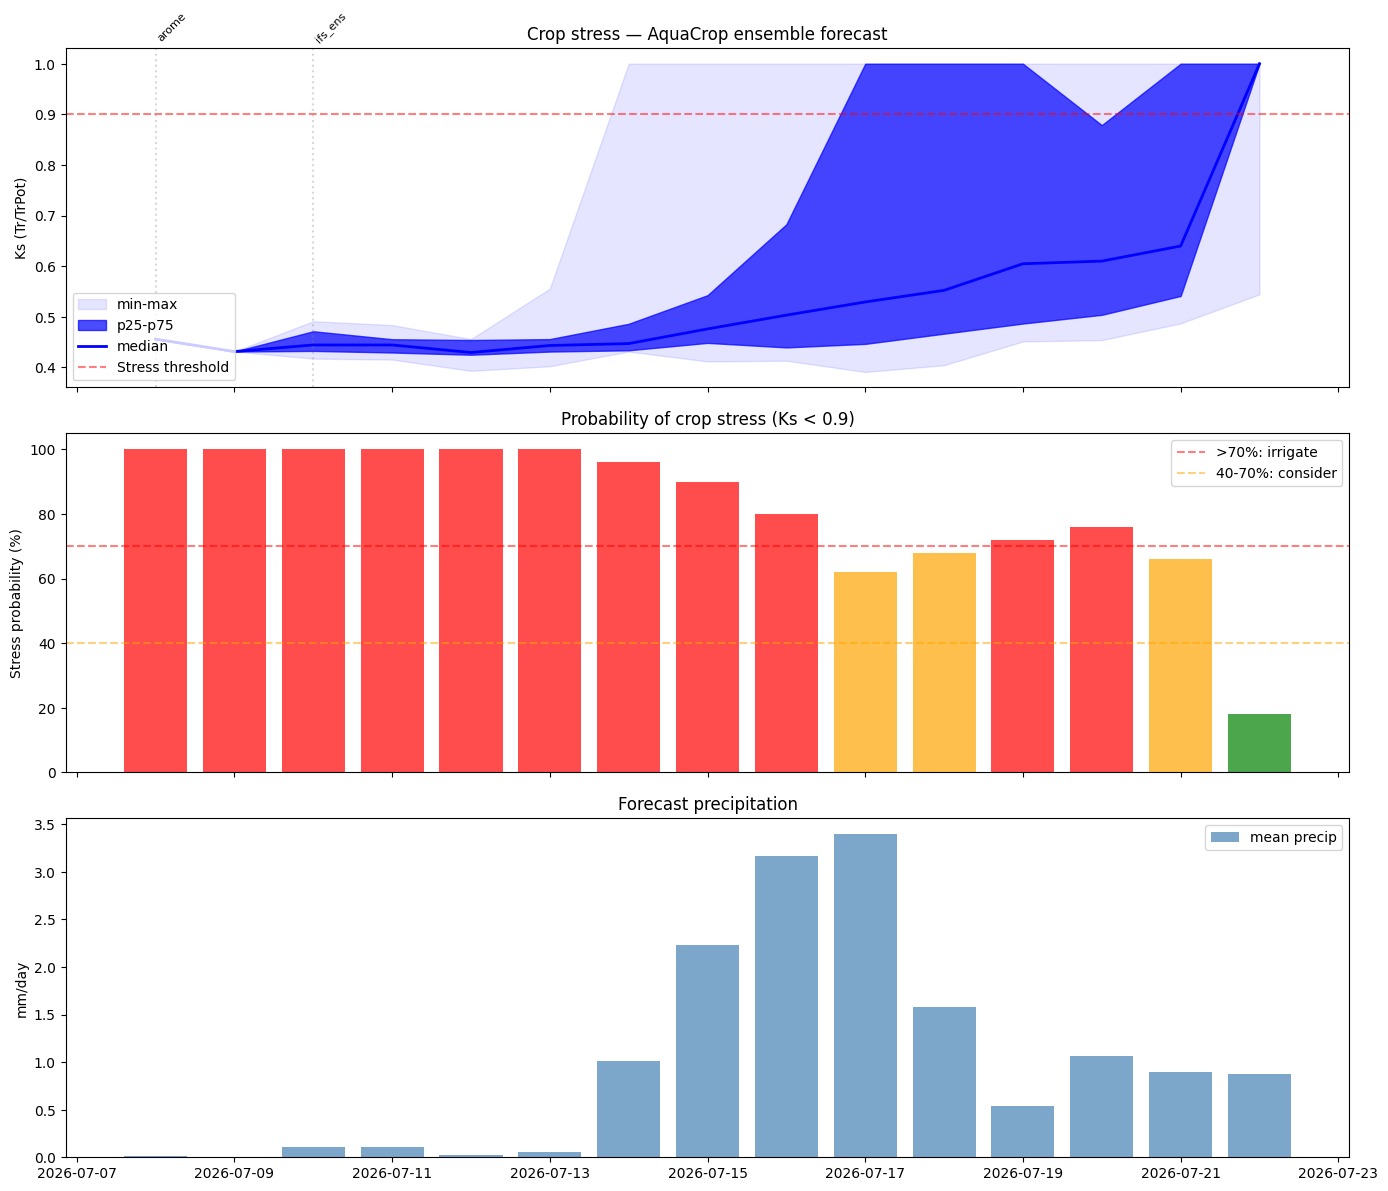

In [11]:
# --- Cell: Plot ensemble forecast (same as before, works unchanged) ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

dates = [d.date for d in stress_report.daily_stats]
sources = [d.source for d in stress_report.daily_stats]

# Ks with ensemble spread
ax = axes[0]
ks_med = [d.ks_median for d in stress_report.daily_stats]
ks_p25 = [d.ks_p25 for d in stress_report.daily_stats]
ks_p75 = [d.ks_p75 for d in stress_report.daily_stats]
ks_min = [d.ks_min for d in stress_report.daily_stats]
ks_max = [d.ks_max for d in stress_report.daily_stats]

ax.fill_between(dates, ks_min, ks_max, alpha=0.1, color="blue", label="min-max")
ax.fill_between(dates, ks_p25, ks_p75, alpha=0.7, color="blue", label="p25-p75")
ax.plot(dates, ks_med, "b-", lw=2, label="median")
ax.axhline(0.9, color="red", ls="--", alpha=0.5, label="Stress threshold")

for i, (d, src) in enumerate(zip(dates, sources)):
    if i == 0 or sources[i] != sources[i - 1]:
        ax.axvline(d, color="gray", ls=":", alpha=0.3)
        ax.text(d, 1.02, src, fontsize=8, rotation=45, transform=ax.get_xaxis_transform())

ax.set_ylabel("Ks (Tr/TrPot)")
ax.set_title("Crop stress — AquaCrop ensemble forecast")
ax.legend(loc="lower left")

# Stress probability
ax = axes[1]
stress_prob = [d.stress_probability for d in stress_report.daily_stats]
colors = ["red" if p > 0.7 else "orange" if p > 0.4 else "green" for p in stress_prob]
ax.bar(dates, [p * 100 for p in stress_prob], color=colors, alpha=0.7)
ax.axhline(70, color="red", ls="--", alpha=0.5, label=">70%: irrigate")
ax.axhline(40, color="orange", ls="--", alpha=0.5, label="40-70%: consider")
ax.set_ylabel("Stress probability (%)")
ax.set_title("Probability of crop stress (Ks < 0.9)")
ax.legend()

# Precipitation
ax = axes[2]
precip_mean = [d.precip_mean for d in stress_report.daily_stats]
ax.bar(dates, precip_mean, color="steelblue", alpha=0.7, label="mean precip")
ax.set_ylabel("mm/day")
ax.set_title("Forecast precipitation")
ax.legend()

plt.tight_layout()
plt.show()


---
## Block 5b — Seasonal Outlook (SEAS5, optional)

PCA analog matching → daily disaggregation → ensemble water balance.
Set `RUN_SEAS5 = True` at the top to enable.

In [1]:
from irrigator.ingestion.cds_client import fetch_seas5, open_seas5
from irrigator.forecasts.seas5_processor import (
    build_era5_monthly_climatology,
    correct_seas5_monthly,
)
from irrigator.forecasts.disaggregation import generate_seasonal_scenarios
from irrigator.decision.seasonal_outlook import compute_seasonal_outlook
import logging
import os
from datetime import date
from pathlib import Path
from datetime import timedelta

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

TODAY = date(2026, 1, 1)  # the date we treat as "today"
#TODAY = date.today()
SIMULATION_START = date(2025, 1, 1)  # start of the growing season simulation
LAST_IRRIGATION = None  # date of last irrigation, or None for rainfed
RUN_SEAS5 = False  # set True to include seasonal outlook (slow)
SHIFT = 0  # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")  # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")  # daily aggregates, cached results

init_year = TODAY.year
init_month = TODAY.month

# Fetch + bias correct SEAS5
fetch_seas5(year=init_year, month=init_month, raw_dir=RAW_DIR)

2026-07-12 16:50:20,601 Requesting SEAS5 2026-01 from CDS...
2026-07-12 16:50:21,057 INFO Request ID is 12330373-56e2-477e-b98a-82b4781d1306
2026-07-12 16:50:21,057 Request ID is 12330373-56e2-477e-b98a-82b4781d1306
2026-07-12 16:50:21,132 INFO status has been updated to accepted
2026-07-12 16:50:21,132 status has been updated to accepted


KeyboardInterrupt: 

In [17]:
outlook = None

if RUN_SEAS5:
    from irrigator.ingestion.cds_client import fetch_seas5, open_seas5
    from irrigator.forecasts.seas5_processor import (
        build_era5_monthly_climatology,
        correct_seas5_monthly,
    )
    from irrigator.forecasts.disaggregation import generate_seasonal_scenarios
    from irrigator.decision.seasonal_outlook import compute_seasonal_outlook

    init_year = TODAY.year
    init_month = TODAY.month

    # Fetch + bias correct SEAS5
    fetch_seas5(year=init_year, month=init_month, raw_dir=RAW_DIR)
    seas5_anom = open_seas5(raw_dir=RAW_DIR, year=init_year, month=init_month)
    era5_clim = build_era5_monthly_climatology(
        start_year=1993, end_year=2016, processed_dir=PROCESSED_DIR,
    )
    seas5_corrected = correct_seas5_monthly(seas5_anom, era5_clim, init_month=init_month)

    # Analog disaggregation (PCA + Mahalanobis + spatial voting)
    scenarios = generate_seasonal_scenarios(
        cfg=cfg,
        era5_daily=era5_daily,
        seas5_corrected=seas5_corrected,
        init_month=init_month,
        n_leads=4,
    )

    # Run water balance under each scenario
    outlook = compute_seasonal_outlook(
        scenarios=scenarios,
        parcel=parcel,
        terrain=terrain,
        soil=soil,
        crop_params=crop_params,
    )

    print(f"\nSeasonal outlook ({outlook.n_members} members):")
    print(f"  Irrigation needed: {outlook.total_irrigation_p25:.0f}–{outlook.total_irrigation_p75:.0f} mm (p25–p75)")
    print(f"  Median: {outlook.total_irrigation_median:.0f} mm")
    print(f"  Stress days: median {outlook.stress_days_median:.0f}")
    print(f"  {outlook.season_description}")
else:
    print("SEAS5 seasonal outlook skipped (set RUN_SEAS5=True to enable)")

SEAS5 seasonal outlook skipped (set RUN_SEAS5=True to enable)


---
## Block 6 — Irrigation Decision

Uses current_state (from AquaCrop) + stress_report (blended AROME + IFS ENS)
to produce an actionable recommendation. The decision logic is unchanged —
it works with the EnsembleStressReport format regardless of whether the
underlying model is FAO-56 bucket or AquaCrop.

In [14]:
from irrigator.decision.rules import compute_recommendation, DecisionParams
from irrigator.decision.output import build_parcel_report, save_report, format_sms
from irrigator.crop.phenology import CropParams

crop_params = CropParams.from_config(parcel.crop, crop_params_path=CROP_PARAMS_PATH)

params = DecisionParams.from_config(
    model_params_path=MODEL_PARAMS_PATH,
    parcel=parcel,
)

advice = compute_recommendation(
    current_state=current_state,
    stress_report=stress_report,
    crop_params=crop_params,
    params=params,
    last_irrigation_date=LAST_IRRIGATION,
)

print(f"\n{'=' * 60}")
print(f"IRRIGATION RECOMMENDATION for {parcel.name}")
print(f"{'=' * 60}")
action = "Irrigate" if advice.irrigate else "No need to irrigate"
print(f"  Action:     {action}")
if advice.dose_mm:
    print(f"  Amount:     {advice.dose_mm:.0f} mm")
print(f"  Confidence: {advice.confidence}")
print(f"  Reason:     {advice.reason}")
print(f"  Stage:      {advice.crop_stage}")
if advice.stress_probability is not None:
    print(f"  Stress probability: {advice.stress_probability:.0%}")
print(f"{'=' * 60}")


KeyError: 'G3'

In [22]:
# Build and save JSON report
print(f"\nSMS: {format_sms(advice)}")



SMS: [IrriGator] 2026-06-23: IRRIGUER 63mm le 2026-06-23. Réserve sol: 59%. Stade: midseason.


---
## Block 6b — Ensemble Irrigation Optimizer

Instead of simple threshold rules, tests candidate irrigation actions
against each IFS ENS member and picks the best action by ensemble consensus.

Tests: no irrigation, plus each (day, dose) combination:
- Days: 0, 1, 2, ..., 7 days from today
- Doses: min (15mm), mid (27mm), max (40mm) from parcel config

For 25 candidates × 50 members = ~1250 AquaCrop runs (~5-8 minutes).

In [12]:
# --- Cell: Run optimizer ---

from irrigator.water_balance.aquacrop_adapter import (
    evaluate_candidates_ensemble,
    recommend_from_optimizer,
    build_candidates,
    evaluate_candidates_ensemble_branching_2level
)

# Build candidate actions from parcel constraints
candidates = build_candidates(parcel, max_days_ahead=10, max_events=2)
print(f"Testing {len(candidates)} candidates × {len(member_forcings)} members")
print(f"Candidates: {[c.label for c in candidates[:5]]}...")

# Evaluate each candidate against the ensemble
# This is the expensive step (~5-8 minutes)

optimizer_results = evaluate_candidates_ensemble_branching_2level(
    historical_forcing=historical_forcing,
    arome_forcing=arome_forcing_48h,
    member_forcings=member_forcings,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    today=TODAY,
    candidates=candidates,
    workers=10,
    stress_threshold=0.9,
    arome_days=2,
)


16:42:21 [irrigator.water_balance.aquacrop_adapter] INFO: Built 54 candidates (1-event: 33, 2-event: 20, 3-event: 0)
16:42:21 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.30m depth, 23 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


Testing 54 candidates × 50 members
Candidates: ['No irrigation', '15mm on day+0', '32mm on day+0', '50mm on day+0', '15mm on day+1']...
MaizeGDD


16:42:23 [irrigator.water_balance.aquacrop_adapter] INFO: Evaluating 54 candidates × 50 members = 2700 AquaCrop branches (two-level branching, arome_days=2, workers=10)
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:1991: RuntimeWarning: invalid value encountered in divide
  ks = np.where(tr_pot > 0.01, tr / tr_pot, 1.0)
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:1991: RuntimeWarning: invalid value encountered in divide
  ks = np.where(tr_pot > 0.01, tr / tr_pot, 1.0)
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:1991: RuntimeWarning: invalid value encountered in divide
  ks = np.where(tr_pot > 0.01, tr / tr_pot, 1.0)
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:1991: RuntimeWarning: invalid value encountered in divide
  ks = np.where(tr_pot > 0.01, tr / tr_pot, 1.0)
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adap

In [11]:
from aquacrop import AquaCropModel

In [13]:
# --- Cell: Optimizer recommendation ---

recommendation = recommend_from_optimizer(optimizer_results, top_x=3)

print(f"\n{'=' * 60}")
print(f"OPTIMIZED IRRIGATION RECOMMENDATION")
print(f"{'=' * 60}")
print(f"  Action:     {recommendation[0]['action']}")
print(f"  Reason:     {recommendation[0]['reason']}")
print(f"  Avoid stress: {recommendation[0]['avoid_stress_pct']:.0%} of members")
print(f"  Mean stress days: {recommendation[0]['mean_stress_days']:.1f}")
if "cost_eur_ha" in recommendation[0]:
    print(f"  Water cost: €{recommendation[0]['cost_eur_ha']:.0f}/ha")
print(f"{'=' * 60}")


print(f"\n{'=' * 60}")
print(f"ALTERNATIVES")
print(f"{'=' * 60}")
print(f"  Action:     {recommendation[1]['action']}")
print(f"  Reason:     {recommendation[1]['reason']}")
print(f"  Avoid stress: {recommendation[1]['avoid_stress_pct']:.0%} of members")
print(f"  Mean stress days: {recommendation[1]['mean_stress_days']:.1f}")
if "cost_eur_ha" in recommendation[1]:
    print(f"  Water cost: €{recommendation[1]['cost_eur_ha']:.0f}/ha")
print(f"{'=' * 60}")
print(f"{'=' * 60}")
print(f"  Action:     {recommendation[2]['action']}")
print(f"  Reason:     {recommendation[2]['reason']}")
print(f"  Avoid stress: {recommendation[2]['avoid_stress_pct']:.0%} of members")
print(f"  Mean stress days: {recommendation[2]['mean_stress_days']:.1f}")
if "cost_eur_ha" in recommendation[2]:
    print(f"  Water cost: €{recommendation[2]['cost_eur_ha']:.0f}/ha")
print(f"{'=' * 60}")


OPTIMIZED IRRIGATION RECOMMENDATION
  Action:     2×50mm on day+1 & +8 (limited benefit)
  Reason:     No action avoids stress in >70% of members. Best option: 8% avoid stress, mean 2.1 stress days
  Avoid stress: 8% of members
  Mean stress days: 2.1

ALTERNATIVES
  Action:     2×50mm on day+1 & +9 (limited benefit)
  Reason:     No action avoids stress in >70% of members. Best option: 8% avoid stress, mean 2.5 stress days
  Avoid stress: 8% of members
  Mean stress days: 2.5
  Action:     2×50mm on day+1 & +10 (limited benefit)
  Reason:     No action avoids stress in >70% of members. Best option: 8% avoid stress, mean 2.9 stress days
  Avoid stress: 8% of members
  Mean stress days: 2.9


In [14]:
recommendation

[{'action': '2×50mm on day+1 & +8 (limited benefit)',
  'reason': 'No action avoids stress in >70% of members. Best option: 8% avoid stress, mean 2.1 stress days',
  'candidate': IrrigationCandidate(events=[(1, 50), (8, 50)], label='2×50mm on day+1 & +8'),
  'avoid_stress_pct': 0.08,
  'mean_stress_days': 2.1,
  'all_results': [CandidateResult(candidate=IrrigationCandidate(events=[(1, 50), (8, 50)], label='2×50mm on day+1 & +8'), member_max_stress=[0.16916131932095035, 0.146010112232125, 0.14249559557072788, 0.17922687469632914, 0.16369452746282032, 0.14790974655290878, 0.19503354732920797, 0.08729662458099874, 0.16696304678759322, 0.16990571670216137, 0.1316383453023825, 0.12478647061995385, 0.1763678294029848, 0.1728679115123355, 0.20540667769959775, 0.15173122600863875, 0.22918337438377767, 0.14597789152239582, 0.23120333184262354, 0.15814927902445164, 0.17778778930119687, 0.2201485356764472, 0.16505704416747358, 0.18700839860433038, 0.17712922182048063, 0.17724705016207332, 0.22387

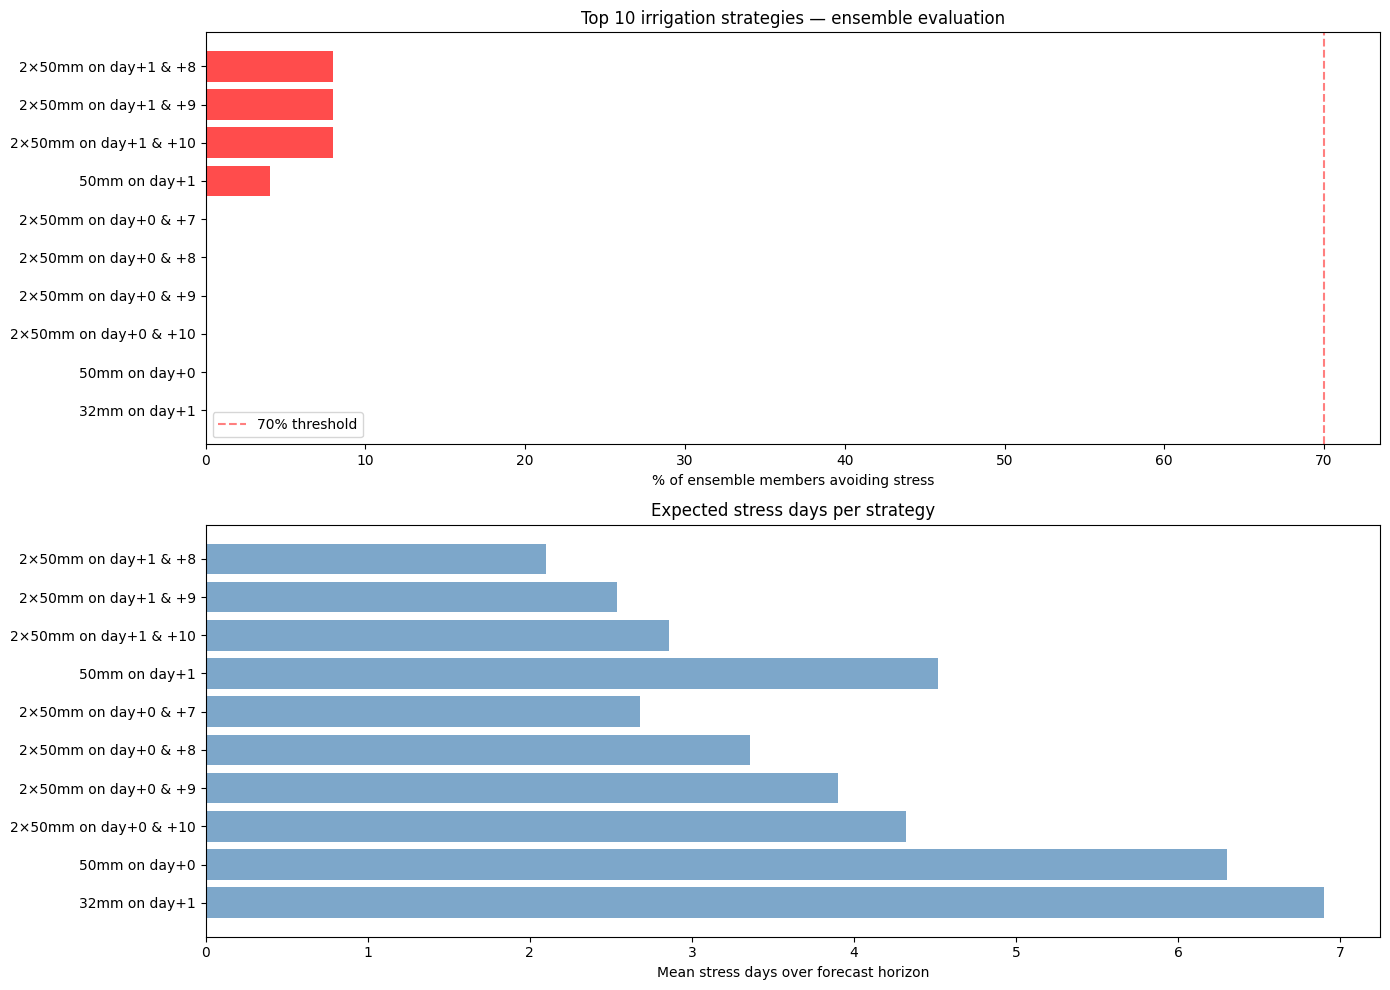

In [15]:
# --- Cell: Plot optimizer comparison ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 10 candidates by avoid_stress_pct
top10 = optimizer_results[:10]

labels = [r.candidate.label for r in top10]
avoid_pct = [r.pct_members_avoid_stress * 100 for r in top10]
mean_stress = [r.mean_stress_days for r in top10]

ax = axes[0]
colors = ["green" if p > 70 else "orange" if p > 40 else "red" for p in avoid_pct]
bars = ax.barh(range(len(top10)), avoid_pct, color=colors, alpha=0.7)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels)
ax.axvline(70, color="red", ls="--", alpha=0.5, label="70% threshold")
ax.set_xlabel("% of ensemble members avoiding stress")
ax.set_title("Top 10 irrigation strategies — ensemble evaluation")
ax.legend()
ax.invert_yaxis()

ax = axes[1]
ax.barh(range(len(top10)), mean_stress, color="steelblue", alpha=0.7)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(labels)
ax.set_xlabel("Mean stress days over forecast horizon")
ax.set_title("Expected stress days per strategy")
ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [29]:
# --- Cell: Detailed comparison table ---

print(f"\n{'Label':<25} {'Avoid %':>8} {'Stress days':>12} {'Mean stress':>12}")
print("-" * 60)
for r in optimizer_results[:15]:
    print(
        f"{r.candidate.label:<25} {r.pct_members_avoid_stress:>7.0%} "
        f"{r.mean_stress_days:>11.1f} {r.mean_max_stress:>11.3f}"
    )



Label                      Avoid %  Stress days  Mean stress
------------------------------------------------------------
2×50mm on day+1 & +5         100%         0.0       0.000
2×50mm on day+1 & +4         100%         0.0       0.000
2×50mm on day+0 & +3         100%         0.0       0.000
2×50mm on day+0 & +4         100%         0.0       0.000
2×50mm on day+0 & +5         100%         0.0       0.007
2×50mm on day+1 & +6         100%         0.0       0.008
2×50mm on day+0 & +6          96%         0.0       0.043
2×50mm on day+1 & +7          80%         0.2       0.067
2×50mm on day+0 & +7          64%         0.4       0.089
2×50mm on day+1 & +8          52%         0.7       0.105
2×50mm on day+0 & +8          30%         1.1       0.125
2×50mm on day+1 & +9          24%         1.4       0.148
2×50mm on day+1 & +10         20%         2.2       0.175
2×50mm on day+1 & +11         16%         2.9       0.197
2×50mm on day+0 & +9          12%         1.9       0.160


---
## Summary: data flow

```
ERA5-Land France-wide cache ──[Block 2: extract + downscale]──→ DailyForcing (parcel)
                                                                       │
                                                      [Blocks 3+4: simulation]──→ current_state
                                                                                        │
AROME France-wide cache ──[extract + downscale]──→ DailyForcing (parcel)                │
                                                         │                              │
IFS ENS download ──[process daily]──[extract]──→ 51× DailyForcing (parcel)              │
                                                         │                              │
                                              [Block 5a: ensemble forward balance]──────┤
                                                                                        │
SEAS5 ──[bias correct]──[PCA analog]──[extract]──→ N× DailyForcing                     │
                                                         │                              │
                                              [Block 5b: seasonal water balance]────────┤
                                                                                        │
                                              [Block 6: decision rules]─────→ IrrigationAdvice
```

All gridded data sources (ERA5-Land, AROME, IFS ENS, SEAS5 analogs) are France-wide.
Parcel extraction happens once through `extract_parcel_forcing()` — one function,
one set of corrections (lapse rate, radiation, wind), for all sources.